# Notebook 04 — Feature Engineering

## Objectives
- Investigate which **transformations** the numeric features might benefit from, and
  validate whether they look reasonable.
- Investigate the **categorical** features and decide on an encoding strategy.
- Define the feature-engineering plan the modelling pipeline will implement.

## Inputs
- `outputs/datasets/cleaned/used_cars_cleaned.csv` (97,442 cleaned rows).

## Outputs
- A documented, justified feature-engineering plan (transformations + encoding) for the
  modelling pipeline. Transformations are applied **inside the pipeline**, so no new
  dataset is saved here.

> Satisfies Merit **7.2** (Data Preparation — a feature-engineering notebook that
> investigates potential transformations and validates whether they are reasonable).

---
## 1. Load the cleaned data

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from feature_engine.transformation import LogTransformer
from feature_engine.encoding import OrdinalEncoder

sns.set_style("whitegrid")

if os.path.basename(os.getcwd()) == "jupyter_notebooks":
    os.chdir(os.path.dirname(os.getcwd()))

df = pd.read_csv("outputs/datasets/cleaned/used_cars_cleaned.csv")
print("Loaded:", df.shape)
df.head()

Loaded: (97442, 10)


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,manufacturer
0,A1,2017,12500,Manual,15735,Petrol,150,55.4,1.4,Audi
1,A6,2016,16500,Automatic,36203,Diesel,20,64.2,2.0,Audi
2,A1,2016,11000,Manual,29946,Petrol,30,55.4,1.4,Audi
3,A4,2017,16800,Automatic,25952,Diesel,145,67.3,2.0,Audi
4,A3,2019,17300,Manual,1998,Petrol,145,49.6,1.0,Audi


---
## 2. Numeric features — distribution and skewness

We check the skewness of each numeric feature. Highly skewed features are candidates for
a transformation (e.g. a log transform), which we test in the next step.

In [2]:
numeric_cols = ["year", "mileage", "engineSize", "mpg", "tax", "price"]
print("Skewness (|value| > 1 is strongly skewed):")
print(df[numeric_cols].skew().sort_values(ascending=False))

Skewness (|value| > 1 is strongly skewed):
mpg           4.372393
price         2.365831
mileage       1.779302
engineSize    1.410312
tax           0.032393
year         -1.909334
dtype: float64


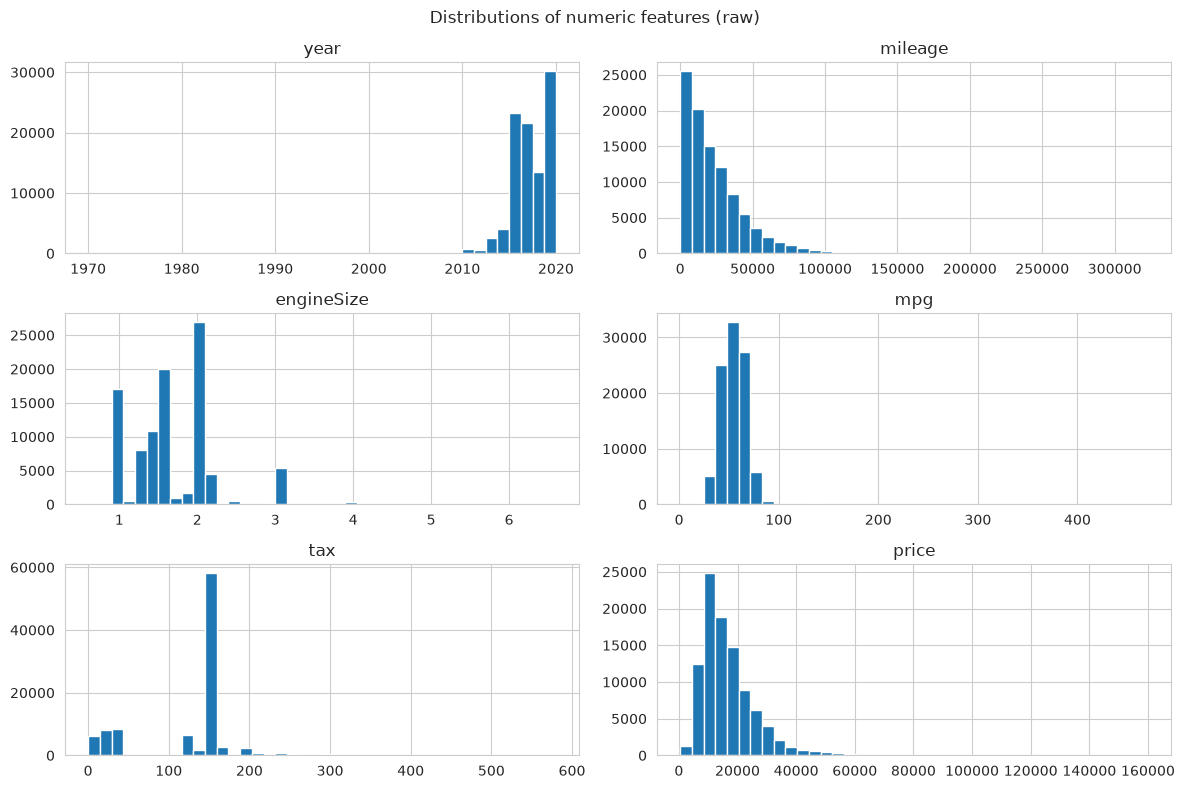

In [3]:
df[numeric_cols].hist(bins=40, figsize=(12, 8))
plt.suptitle("Distributions of numeric features (raw)")
plt.tight_layout()
plt.show()

---
## 3. Test a transformation on the skewed features

`mileage` and `price` are right-skewed. We apply a **log transform** and validate whether
it is reasonable by comparing the skewness and distributions before and after.

In [4]:
log_t = LogTransformer(variables=["mileage", "price"])
df_log = log_t.fit_transform(df.copy())

print("Skew before log:")
print(df[["mileage", "price"]].skew())
print("\nSkew after log:")
print(df_log[["mileage", "price"]].skew())

Skew before log:
mileage    1.779302
price      2.365831
dtype: float64

Skew after log:
mileage   -2.333143
price     -0.076239
dtype: float64


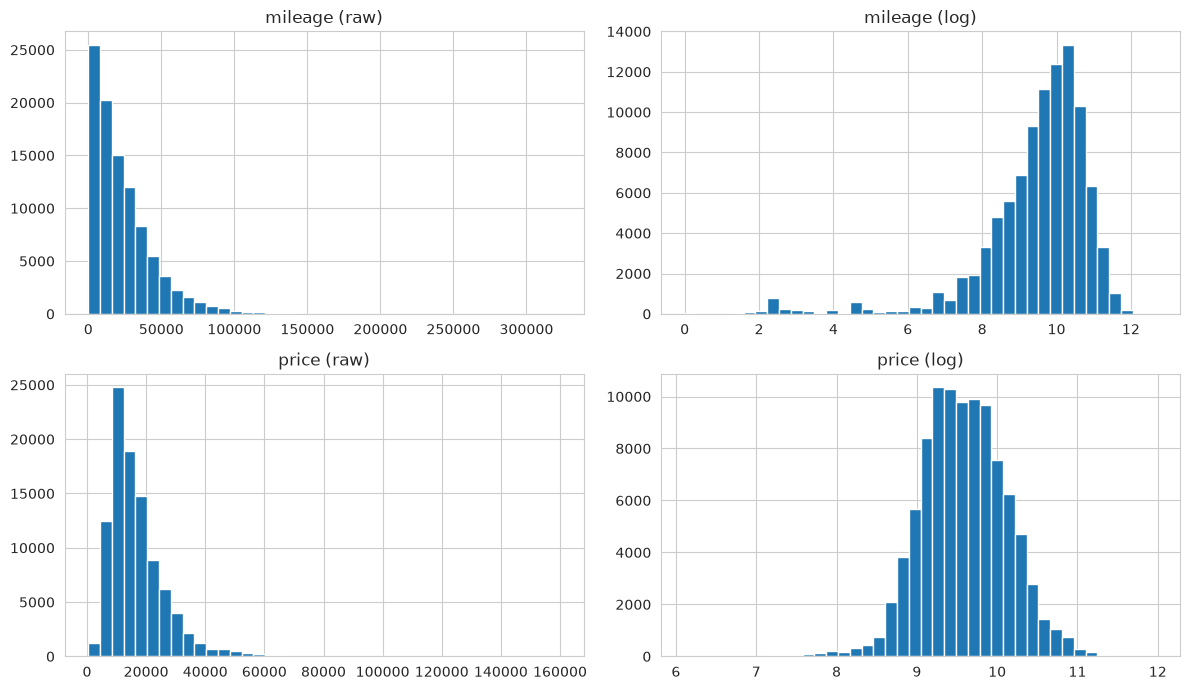

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
df["mileage"].hist(ax=axes[0, 0], bins=40); axes[0, 0].set_title("mileage (raw)")
df_log["mileage"].hist(ax=axes[0, 1], bins=40); axes[0, 1].set_title("mileage (log)")
df["price"].hist(ax=axes[1, 0], bins=40); axes[1, 0].set_title("price (raw)")
df_log["price"].hist(ax=axes[1, 1], bins=40); axes[1, 1].set_title("price (log)")
plt.tight_layout()
plt.show()

---
## 4. Categorical features — cardinality

We check how many unique values each categorical feature has. High cardinality affects
which encoding is sensible (one-hot encoding a high-cardinality column creates many
columns).

In [6]:
categorical_cols = ["transmission", "fuelType", "manufacturer", "model"]
print("Unique values per categorical feature:")
print(df[categorical_cols].nunique())

Unique values per categorical feature:
transmission      4
fuelType          5
manufacturer      9
model           197
dtype: int64


We demonstrate the chosen encoding (**ordinal**) so the effect is visible: each category
is mapped to an integer, keeping the feature count unchanged.

In [7]:
ord_enc = OrdinalEncoder(encoding_method="arbitrary", variables=categorical_cols)
df_enc = ord_enc.fit_transform(df.copy())
df_enc[categorical_cols].head()

,transmission,fuelType,manufacturer,model
0,0,0,0,0
1,1,1,0,1
2,0,0,0,0
3,1,1,0,2
4,0,0,0,3


## 5. Feature-engineering plan
**Numeric features** — the log transform normalises `price` almost perfectly
(skew 2.37 → -0.08), but for `mileage` it *over-corrects* into a left skew (1.78 → -2.33),
showing no single transform is ideal for every variable. This is moot for us: the model
family we will use is a **tree-based ensemble**, which is invariant to monotonic transforms
and to feature scale, so numeric transformations are **not required** for performance. We
keep the raw numeric values for interpretability, having investigated and confirmed the
transforms add nothing for trees.

**Categorical features** — `transmission` (4), `fuelType` (5) and `manufacturer` (9) are
low-cardinality; `model` is high-cardinality (197 values). One-hot encoding `model` would
create ~197 sparse columns, so we use **ordinal encoding** for all categoricals: compact and
well suited to tree models, which split on the encoded values rather than assuming an order.

**Where transformations are applied** — encoding is built **into the modelling Pipeline**
(not saved as a separate dataset), so the deployed app can accept raw car details and the
pipeline encodes them consistently at prediction time. The cleaned dataset
(`used_cars_cleaned.csv`) is the input to that pipeline.

Next: **Notebook 05 — Modelling & Evaluation** (CRISP-DM: Modelling).